#IMPORTING RELEVANT LIBRARIES

In [ ]:
!pip install snntorch  # snnTorch is not pre-installed on Google Colab or local IDEs. Hence, needs to be installed manually.
# !pip install torch torchvision  # PyTorch is pre-installed on Google Colab but not on most local IDEs. Install manually if using locally.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 13.5 MB/s eta 0:00:00


In [ ]:
# For loading the Dataset and creating DataLoaders:
from torch.utils.data import DataLoader, random_split, ConcatDataset
from torchvision import datasets, transforms

# For network connectivity maps and tensor operations
import torch
import torch.nn as nn

# For Leaky Integrate-and-Fire (LIF) neuron models
import snntorch as snn

# For plotting
import matplotlib.pyplot as plt
import itertools

# For numeric arrays and defining poisson noise
import numpy as np
import random

# For hardware and software specifications
import platform
import psutil
import pandas as pd

# For saving the model to Google Drive
from google.colab import drive
#drive.mount('/content/drive')

#Getting static MNIST dataset

In [ ]:
print("MENU\nMNIST: 0\nFashion-MNIST: 1")
choice_dataset=int(input("Enter dataset preference: "))
while(choice_dataset!=1 and choice_dataset!=0):
  print("Invalid Choice. Try Again.")
  choice_dataset=int(input("Enter dataset preference: "))
print("You have chosen ", end="")
if choice_dataset == 1:
  print("Fashion-MNIST")
else:
  print("MNIST")

MENU
MNIST: 0
Fashion-MNIST: 1
Enter dataset preference: 1
You have chosen Fashion-MNIST


In [ ]:
print("Would you like to add noise to the SNN?\nMENU\nNO NOISE : 0\nNOISE : 1")
choice_noise=int(input("Enter choice: "))
while(choice_noise!=1 and choice_noise!=0):
  print("Invalid Choice. Try Again.")
  choice_noise=int(input("Enter choice: "))
print("You have chosen ", end="")
if choice_noise == 1:
  print("NOISE")
else:
  print("NO NOISE")

Would you like to add noise to the SNN?
MENU
NO NOISE : 0
NOISE : 1
Enter choice: 1
You have chosen NOISE


In [ ]:
batch_size = 128 # Number of images passed at a time to the model (used in DataLoader below).
dtype = torch.float # Data type for tensors

In [ ]:
if choice_dataset == 0:
  data_path='/tmp/data/mnist' # Path to download/store the MNIST dataset
else:
  data_path='/tmp/data/fashion-mnist' # Path to download/store the Fashion-MNIST dataset


In [ ]:
# Define Image transforms.
# Except for ".ToTensor()", these transforms are unnecessary for F-MNIST images.
transform = transforms.Compose([
            transforms.Resize((28, 28)), # Redundant: Resizes images to 28 x 28 pixels.
            transforms.Grayscale(), # Redundant: If image has 3 channels (RGB), this makes it single channel (grayscale).
            transforms.ToTensor(), # Required: Converts PIL image to a PyTorch tensor and scales pixel values to [0, 1].
            transforms.Normalize((0,), (1,))]) # Redundant: Normalizes the image tensor to have a specific mean (0) and standard deviation (1) for each channel.

# Dataset stores the samples of images and their corresponding labels, using the default train-test split
train_data = datasets.FashionMNIST(data_path, train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST(data_path, train=False, download=True, transform=transform)

# Custom Split:
full_dataset = ConcatDataset([train_data, test_data ]) # Concatenates train and test to get full dataset.
total_size = len(full_dataset)  # No. of images in full dataset: 70,000
# Re-split full dataset into 70% training (49,000) and 30% test (21,000)
train_size = int(0.7 * total_size)
test_size = total_size - train_size
# random_split (from torch.utils.data) randomly divides full_dataset based on above train_size and test_size.
# Note: random_split does not preserve class distribution (i.e., not stratified).
train_, test_ = random_split(full_dataset, [train_size, test_size])

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 165kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.03MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.6MB/s]


In [ ]:
# DataLoader creates an iterable shuffled batches of the dataset and drops incomplete batches
train_loader = DataLoader(train_, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(test_, batch_size=batch_size, shuffle=True, drop_last=True)

# GENERATING POISSON NOISE

In [ ]:
# This method of Poisson spike train generation is as per Prof. David Heeger's handout 'Poisson Model of Spike Generation', 2000
# It follows a homogeneous Poisson process as the firing rate does not vary with time.

def poisson_spike_generator(rate, neuron_num): # Parameters: firing rate in Hz, number of neurons
    rand_nums = torch.rand(neuron_num)  # Tensor of size "neuron_num" containing random numbers between 0 and 1.
    spike_train = (rand_nums < rate/1000).float()  # 1 when the random no. is less than rate, else 0. Divided rate by 1000 since each time step is a millisecond.
    #print(torch.sum(spike_train), end=" ") # Shows number of spikes in the spike train
    return spike_train

In [ ]:
def input_generator(rate,neuron_num): # Parameters same as "poisson_spike_generator()"
  input={} # Dictionary with batch indices as keys and spike trains as values.
  for n in range(batch_size):
    input[n]=poisson_spike_generator(rate,neuron_num)
  inputs=torch.stack(list(input.values()))  # Dictionary converted to tensor of shape: (batch_size, neuron_num, num_steps)
  #print("inputs:",inputs.size())
  return inputs

In [ ]:
rate=5 #In Hz
print(f"rate:{rate}")

rate:5


# DEFINING THE NETWORK

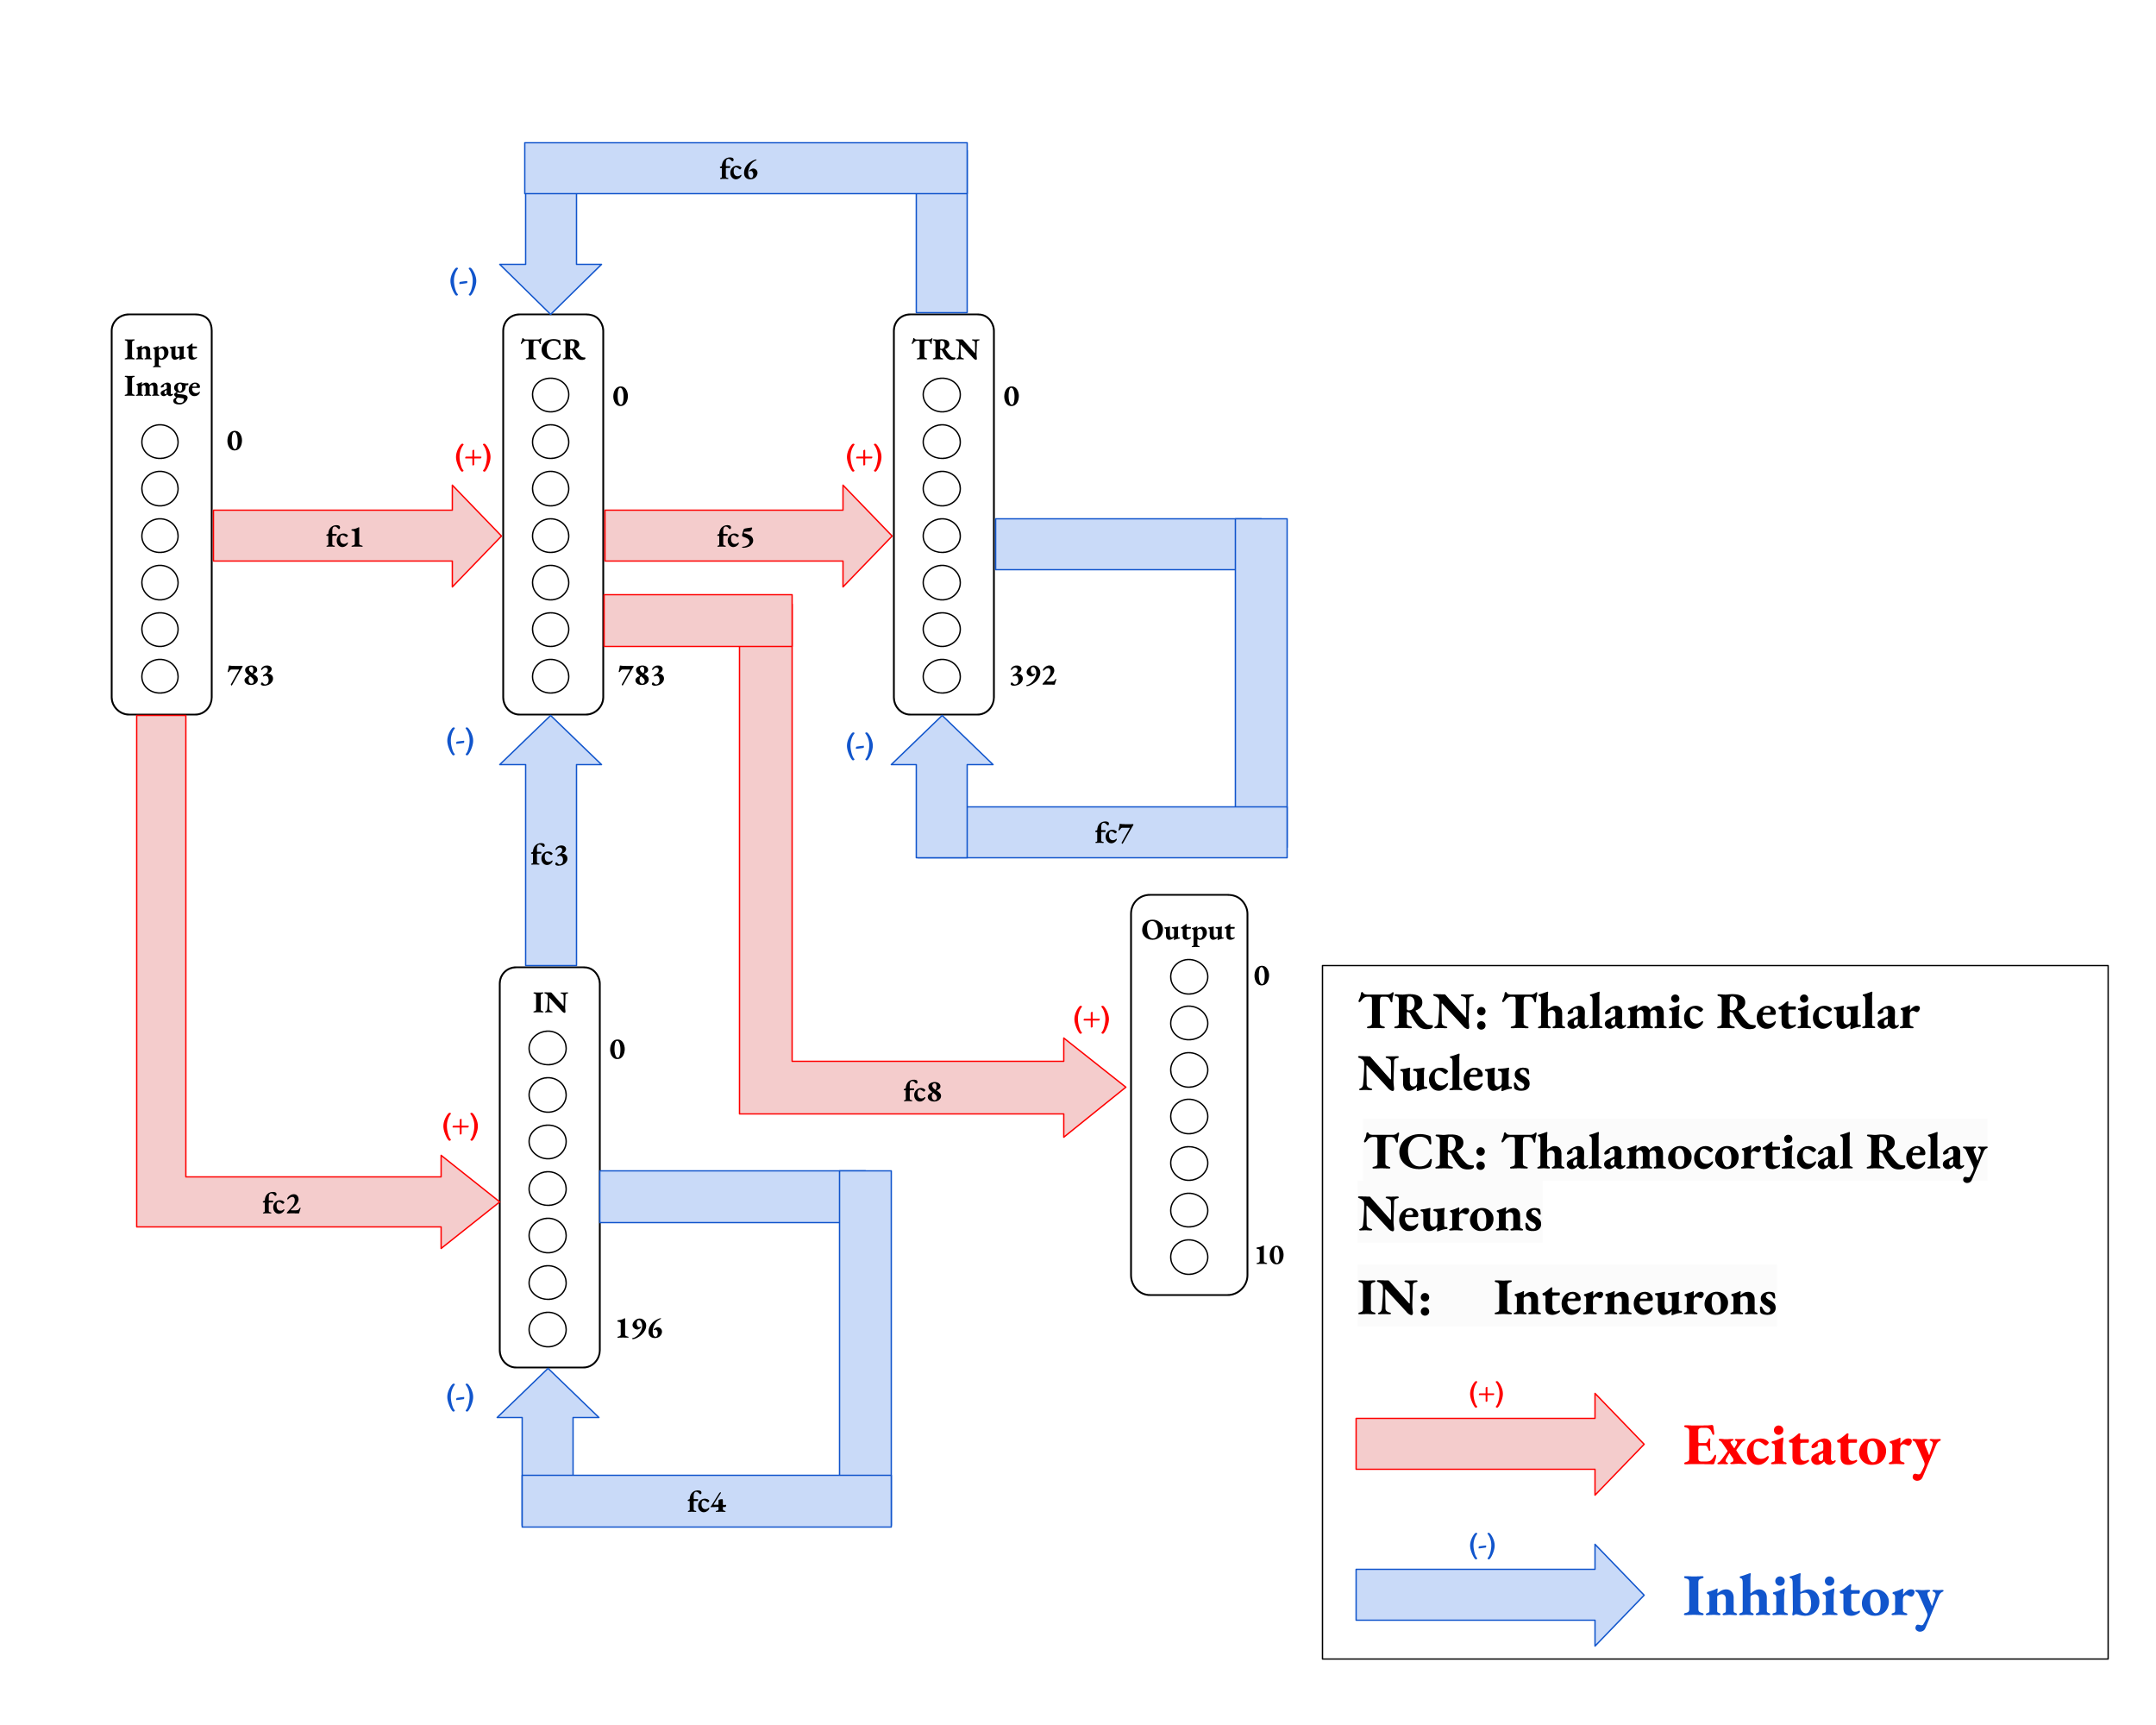

In [ ]:
duration=0.025  # Total simulation time in milliseconds (ms)
dt = 0.001    # A single time step's size (ms)
num_steps=int(duration/dt) # Total number of time steps

In [ ]:
#Scaling number of neurons down to 60% for sparsity
neurons=int(0.6*784)
input_neurons = 784

# TCR:TRN:IN is 4:2:1. These ratios and the nature of the neuron populations of the LGN are as per
# Sen Bhattacharya et al., “A spiking neural network model of the lateral geniculate nucleus on the SpiNNaker machine”
tcr_neurons = neurons
trn_neurons = int(neurons / 2)
in_neurons = int(neurons / 4)
output_neurons=10 # Since there are 10 output classes in the case of FMNIST and MNIST

In [ ]:
#Define Network
class Net(nn.Module):
    def __init__(self, input_neurons, tcr_neurons, trn_neurons, in_neurons):
        super(Net, self).__init__()
        # Initializes layers. Performs linear transformation on input data
        # y=xW^T+b where y is output, x is input, W^T is transpose of weight matrix. Bias (b) is not included here.
        self.fc1 = nn.Linear(input_neurons,tcr_neurons, bias=False)
        self.fc2 = nn.Linear(input_neurons, in_neurons, bias=False)
        self.fc3 = nn.Linear(in_neurons, tcr_neurons, bias=False)
        self.fc4 = nn.Linear(in_neurons, in_neurons, bias=False)
        self.fc5 = nn.Linear(tcr_neurons, trn_neurons, bias=False)
        self.fc6 = nn.Linear(trn_neurons, tcr_neurons, bias=False)
        self.fc7 = nn.Linear(trn_neurons, trn_neurons, bias=False)
        self.fc8 = nn.Linear(tcr_neurons, output_neurons, bias=False)

        # Beta values were set heuristically. Beta and Threshold are learnable parameters. Default threshold is used i.e 1.
        # Default reset mechanism i.e reset by subtraction is used where threshold is subtracted from membrane potential when a spike occurs.
        self.lif1 = snn.Leaky(beta=0.95, learn_beta=True, learn_threshold=True) #in
        self.lif2 = snn.Leaky(beta=0.9, learn_beta=True, learn_threshold=True) #tcr
        self.lif3 = snn.Leaky(beta=0.9, learn_beta=True, learn_threshold=True) #trn
        self.lif4 = snn.Leaky(beta=0.9, learn_beta=True, learn_threshold=True) #output

        #Initial membrane potential kept as 1
        self.mem1 = torch.ones(1)
        self.mem2 = torch.ones(1)
        self.mem3 = torch.ones(1)
        self.mem4 = torch.ones(1)
        self.spk4 = torch.ones(1)


    #FORWARD PASS
    def forward(self,flattened_images):
      spike_in=flattened_images #Plain pixel intensity values

      # Initial dummy value inputs needed for self-loop connectivities of TRN and IN
      spk2 = torch.zeros(trn_neurons)
      spk3 = torch.zeros(in_neurons)

      # Initialize tensors to store membrane potentials and spikes of output layer over time
      full_mem=torch.zeros(num_steps, batch_size, output_neurons)
      full_spk=torch.zeros(num_steps, batch_size, output_neurons)

      if choice_noise == 1:
        print("noise")
        # Connectivities from Poisson Spike generator to network
        fc9 = nn.Linear(tcr_neurons,tcr_neurons, bias = False)
        fc10 = nn.Linear(in_neurons,in_neurons, bias = False)

        with torch.no_grad(): # Weights of Poisson connectivities are not learnable.
          # Weights are clamped such that they are strictly positive (upper limit is redundant).
          fc9.weight.data=torch.clamp(fc9.weight.data, min=0, max=1)
          fc10.weight.data=torch.clamp( fc10.weight.data, min=0, max=1)

        poisson_noise_in = input_generator(rate, in_neurons)
        poisson_noise_tcr = input_generator(rate, tcr_neurons)


      # NETWORK SIMULATION: Iterates over 128 images for 25 time steps each
      for step in range(num_steps):
          # IN layer
          if choice_noise == 1:
            cur3 = self.fc2(spike_in) + self.fc4(spk3) + fc10(poisson_noise_in) #Image input, self input, noise
          else:
            cur3 = self.fc2(spike_in) + self.fc4(spk3) #Image input, self input
          spk3, self.mem3 = self.lif1(cur3, self.mem3)

          # TCR layer
          if choice_noise == 1:
            cur1 = self.fc1(spike_in) + self.fc6(spk2) + self.fc3(spk3) + fc9(poisson_noise_tcr) #Image, TRN and IN feedback, noise
          else:
            cur1 = self.fc1(spike_in) + self.fc6(spk2) + self.fc3(spk3) #Image, TRN and IN feedback
          spk1, self.mem1 = self.lif2(cur1, self.mem1)

          # TRN layer
          cur2 = self.fc5(spk1) + self.fc7(spk2)  #TCR and TRN feedback
          spk2, self.mem2 = self.lif3(cur2, self.mem2)

          # OUTPUT layer
          cur4 = self.fc8(spk1)  #TCR input
          self.spk4, self.mem4 = self.lif4(cur4, self.mem4)

          # Record outputs
          full_mem[step] =  self.mem4
          full_spk[step] = self.spk4

      #print("full_mem.size:",full_mem.size()) # Both of shape: (num_steps, batch size, output layer neurons)
      return full_mem, full_spk

# INSTANTIATING MODEL, INITIAL WEIGHT CLAMPING

In [ ]:
device = torch.device("cuda") # Sets the device to GPU (CUDA), assuming CUDA is available

# Instantiate model
model = Net(input_neurons, tcr_neurons, trn_neurons, in_neurons)

# Weight Clamping:
upperlim=2.0 #excitatory weights stay below 2
lowerlim=-2.0 #inhibitory weights stay above -2
mid=0.0 #excitatory weights stay above 0, inhibitory weights stay below 0
for name, param in model.named_parameters():
  if "fc3" in name or "fc4" in name  or "fc6" in name  or "fc7" in name:  #inhibitory connectivities
      param.data.clamp_(min=lowerlim, max=mid)
  elif "fc1" in name or "fc2" in name  or "fc5" in name: #excitatory connectivities
      param.data.clamp_(min=mid, max=upperlim)
  elif "fc8" in name: #tcr to output. A connectivity that's not purely excitatory showed better results.
    param.data.clamp_(min=lowerlim, max=upperlim)
  if "fc4" in name or "fc7" in name:
    param.data.fill_diagonal_(0) #Giving self-loop weight matrices zero diagonal so neurons don't receive their own output as input.

In [ ]:
#print(f"fc1:{model.fc1.weight},\nfc2:{model.fc2.weight},\nfc3:{model.fc3.weight},\nfc4:{model.fc4.weight},\nfc5:{model.fc5.weight},\nfc6:{model.fc6.weight},\nfc7:{model.fc7.weight},\nfc8:{model.fc8.weight}")

# SAVING INITIAL WEIGHTS

In [ ]:
#torch.save(model.state_dict(), "/content/drive/My Drive/Initial.pth")

# DEFINING OPTIMIZER AND LOSS FUNCTION

In [ ]:
# The Adam optimizer adaptively updates the model's parameters (weights and biases) using gradients from backpropagation to minimize the loss function during training.
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, betas=(0.9, 0.999)) # Parameters are as per snnTorch Tutorial 5: https://snntorch.readthedocs.io/en/latest/tutorials/tutorial_5.html
# Loss function using log measures the difference between the predicted outputs of the model and the true target values.
loss = nn.CrossEntropyLoss()

# ACCURACY CALCULATION FOR EACH ITERATION WITHIN AN EPOCH

In [ ]:
def print_batch_accuracy(data, targets, train=False):
    #Forward pass
    _,output = model(data)  # Pass data to model. 'output' holds spikes (full_spk).

    _, idx = output.sum(dim=0).max(1)  # Sums up spikes over time steps, then finds the index of neuron with maximum spikes to get the predicted class.

    # Calculate accuracy by comparing predictions with actual targets.
    acc = (targets == idx).float().mean().item() # gives mean of a boolean tensor where 1=>True and 0=>False

    # Prints results as percentage
    if train:
        print(f"Train set accuracy for a single minibatch: {acc*100:.2f}%")
        accuracy_train[epoch][iter_counter] =(acc*100)
    else:
        print(f"Test set accuracy for a single minibatch: {acc*100:.2f}%")
        accuracy_test[epoch][iter_counter] =(acc*100)

# FUNCTION TO PRINT TRAINING PROGRESS AND MODEL WEIGHTS

In [ ]:
def train_printer(data, targets, epoch,  iter_counter, loss_hist, test_loss_hist, test_data, test_targets):
    # Prints accuracy and loss at intervals during training.
    print(f"Epoch {epoch}, Iteration {iter_counter}")
    print(f"Train Set Loss: {loss_hist[epoch][iter_counter]:.2f}")
    print(f"Test Set Loss: {test_loss_hist[epoch][iter_counter]:.2f}")
    print(f"fc1:{model.fc1.weight},\nfc2:{model.fc2.weight},\nfc3:{model.fc3.weight},\nfc4:{model.fc4.weight},\nfc5:{model.fc5.weight},\nfc6:{model.fc6.weight},\nfc7:{model.fc7.weight},\nfc8:{model.fc8.weight}")
    print("\n")

# TRAINING LOOP

In [ ]:
batches= 380 # Number of batches to train on.
num_epochs = 5 # Can be varied.
num_iterations = batches

# Data structures for plotting:
loss_hist = np.full((num_epochs, num_iterations), np.nan, dtype=float)
test_loss_hist = np.full((num_epochs, num_iterations), np.nan, dtype=float)
accuracy_train=np.full((num_epochs, num_iterations), np.nan, dtype=float)
accuracy_test= np.full((num_epochs, num_iterations), np.nan, dtype=float)

# TRAINING LOOP
for epoch in range(num_epochs):
    iter_counter = 0 # Local iteration counter (resets every epoch).
    train_batch = iter(train_loader)

    # Minibatch training loop
    for data, targets in train_batch: # No. of loops = No. of batches
        print(f"Epoch {epoch}, Iteration {iter_counter}:\n")
        data = data
        targets = targets
        print("data size:", data.size()) # Shape must be: [128, 1, 28, 28]
        model.train() # Set model to training mode

        # Call forward pass
        mem_rec,_ = model(data.view(batch_size, -1))
        print("mem_rec (model output) size:",mem_rec.size()) # Shape must be [25, 128, 10]
        print("targets size:", targets.size()) # Shape must be equal to batch size i.e 128

        # Training Loss
        loss_val = torch.zeros((1), dtype=dtype) # Stores loss of a batch.
        for step in range(num_steps):
            loss_val += loss(mem_rec[step], targets)

        # Backpropgation
        optimizer.zero_grad() # Clears previous gradients
        loss_val.backward() # Computes the gradients of the loss function with respect to each model parameter using autograd.

        for name, param in model.named_parameters(): # Checks for gradient errors. If either statement is printed, try varying LIF parameters.
          if param.grad is None:
              print(f"{name} gradient is None!")
          elif param.grad.norm().item()==0:
              print(f"{name} gradient norm is zero.")

        optimizer.step() # Updates model parameters based on gradients

        # Weight Clamping:
        for name, param in model.named_parameters():
          if "fc3" in name or "fc4" in name  or "fc6" in name  or "fc7" in name: # if inhibitory connection
              param.data.clamp_(min=lowerlim, max=mid)
          elif "fc1" in name or "fc2" in name  or "fc5" in name: # if excitatory connection
              param.data.clamp_(min=mid, max=upperlim)
          elif  "fc8" in name:
              param.data.clamp_(min=lowerlim, max=upperlim)
          if "fc4" in name or "fc7" in name:
              param.data.fill_diagonal_(0)

        # Stores loss history
        loss_hist[epoch][iter_counter] = loss_val.item()

        # Validation testing
        with torch.no_grad(): # Disables gradients.
            model.eval() # Sets model to testing mode
            test_data, test_targets = next(iter(test_loader)) # Tests the same batch at every iteration of the loop
            test_data = test_data
            test_targets = test_targets

            # Call forward pass
            test_mem, _ = model(test_data.view(batch_size, -1))

            # Validation Testing loss
            test_loss = torch.zeros((1), dtype=dtype)
            for step in range(num_steps):
                test_loss += loss(test_mem[step], test_targets)
            test_loss_hist[epoch][iter_counter] = test_loss.item()

            # Print train and test loss, accuracy
            print_batch_accuracy(data.view(batch_size, -1), targets, train=True)
            print_batch_accuracy(test_data.view(batch_size, -1), test_targets, train=False)
            if iter_counter==0 or iter_counter==batches*0.25 or iter_counter==batches*0.5 or iter_counter==batches*0.75 or iter_counter==batches-1: #printing weights after forward pass on last image in batch
                train_printer(data,targets,epoch,iter_counter,loss_hist,test_loss_hist,test_data, test_targets)

        print("---------------------------------------------------------------------------------------------------------------------------------------------------------------")
        iter_counter +=1
        if iter_counter==batches:
          break
    print("====================================================================================================================================================================")

Streaming output truncated to the last 5000 lines.
        [-0.0176, -0.0016, -0.0020,  ...,  0.0000, -0.0300, -0.0636],
        [-0.0217, -0.0244, -0.0132,  ..., -0.0849,  0.0000, -0.1008],
        [-0.0252, -0.0016, -0.0022,  ..., -0.0142, -0.0757,  0.0000]],
       requires_grad=True),
fc5:Parameter containing:
tensor([[5.4294e-04, 1.1875e-02, 1.3991e-02,  ..., 5.9227e-06, 4.0428e-04,
         2.1062e-05],
        [1.8318e-02, 2.9399e-02, 3.3260e-03,  ..., 6.3568e-03, 3.0785e-04,
         2.1324e-02],
        [8.0520e-03, 0.0000e+00, 2.1428e-02,  ..., 8.2531e-05, 1.8935e-02,
         3.1035e-02],
        ...,
        [2.2946e-04, 2.0164e-02, 7.9833e-03,  ..., 1.7632e-02, 1.8845e-04,
         1.8809e-02],
        [3.6542e-02, 4.2594e-02, 2.4996e-02,  ..., 1.1174e-03, 7.6294e-04,
         5.2147e-04],
        [5.5127e-05, 4.6673e-04, 1.1282e-02,  ..., 0.0000e+00, 1.8238e-02,
         1.4619e-03]], requires_grad=True),
fc6:Parameter containing:
tensor([[-0.0032, -0.0327, -0.0015,  ...,

# PLOTTING LOSS AND ACCURACY OF SINGLE EPOCH

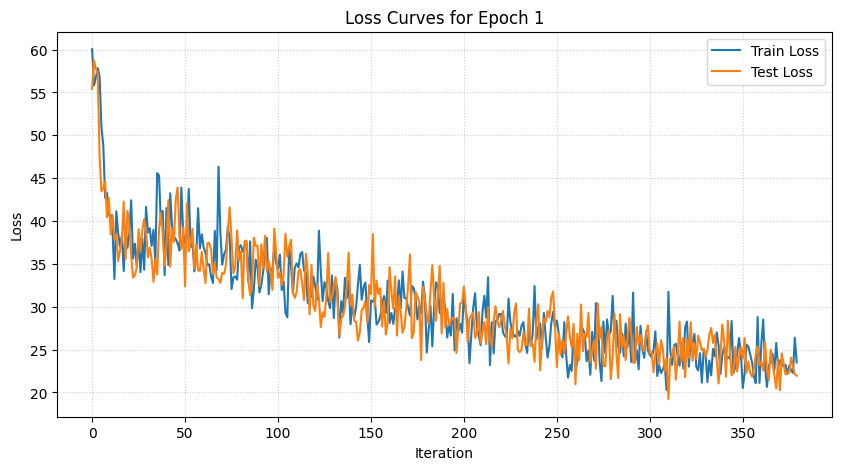

In [ ]:
# Plot train and test LOSS for a SINGLE EPOCH
epoch_idx = 0  # Index of the epoch to plot
fig = plt.figure(facecolor="w", figsize=(10, 5))
plt.plot(loss_hist[epoch_idx])
plt.plot(test_loss_hist[epoch_idx])
plt.title("Loss Curves for Epoch 1")
plt.legend(["Train Loss", "Test Loss"])
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

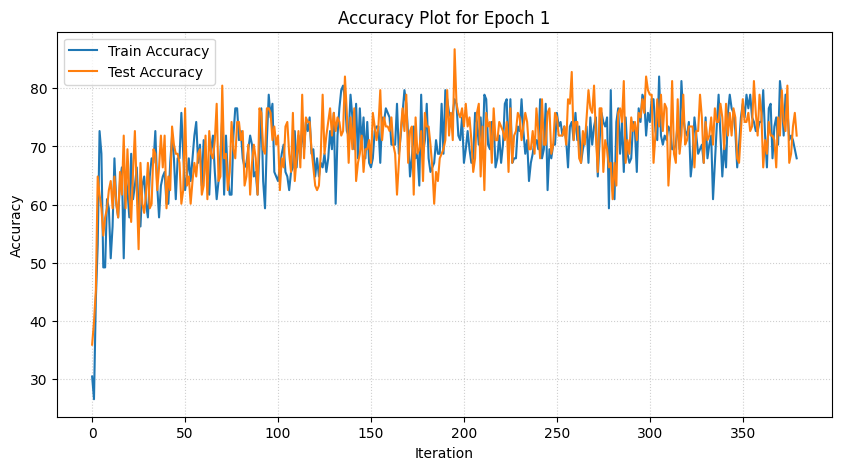

In [ ]:
# Plot train and test ACCURACY for a SINGLE EPOCH
epoch_idx = 0  # Index of the epoch to plot
fig = plt.figure(facecolor="w", figsize=(10, 5))
plt.plot(accuracy_test[epoch_idx])
plt.plot(accuracy_train[epoch_idx])
plt.title("Accuracy Plot for Epoch 1")
plt.legend(["Train Accuracy", "Test Accuracy"])
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# PLOTTING LOSS AND ACCURACY FOR ALL EPOCHS

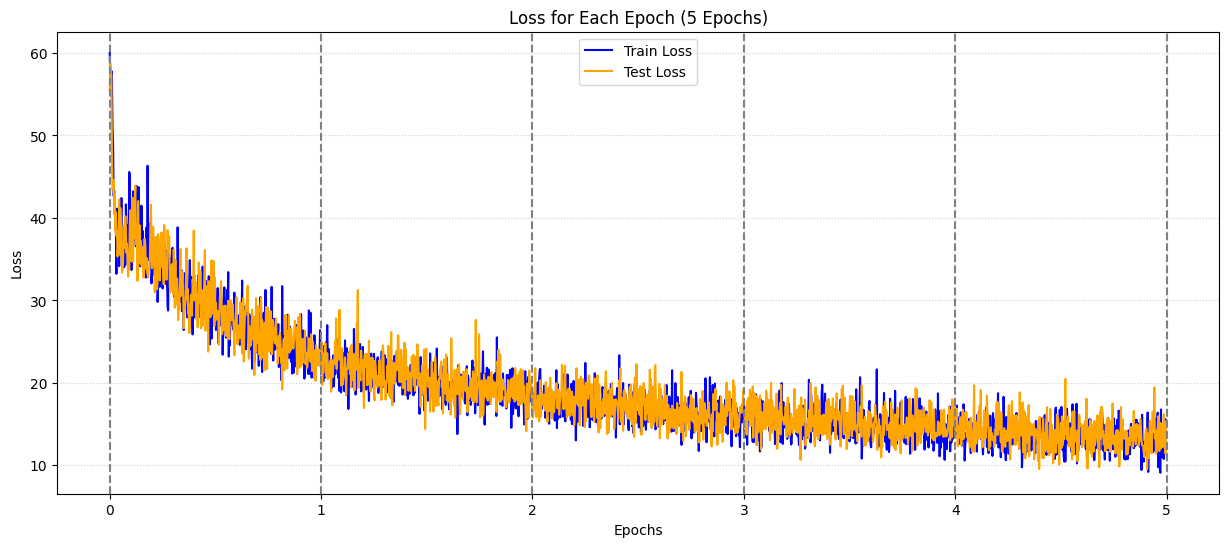

In [ ]:
# Plotting Loss
plt.figure(figsize=(15, 6))

# Plot Train Data in one color
for i in range(num_epochs):
    plt.plot(range(i * num_iterations, (i + 1) * num_iterations),
             loss_hist[i],
             color='blue')  # Fixed color for train

# Plot Test Data in another color
for i in range(num_epochs):
    plt.plot(range(i * num_iterations, (i + 1) * num_iterations),
             test_loss_hist[i],
             color='orange')  # Fixed color for test

# Add vertical grid lines for epoch boundaries
for i in range(0, num_epochs+1):
    plt.axvline(x=i * num_iterations, color='gray', linestyle='--')

plt.title(f"Loss for Each Epoch ({num_epochs} Epochs)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
epoch_ticks = [i * num_iterations for i in range(num_epochs + 1)]  # Epoch start points
epoch_labels = [f"{i}" for i in range(num_epochs + 1)]  # Labels
plt.xticks(epoch_ticks, epoch_labels)

# Legend for Train and Test
plt.plot([], [], color='blue', label='Train Loss')
plt.plot([], [], color='orange', label='Test Loss')
plt.legend()

plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

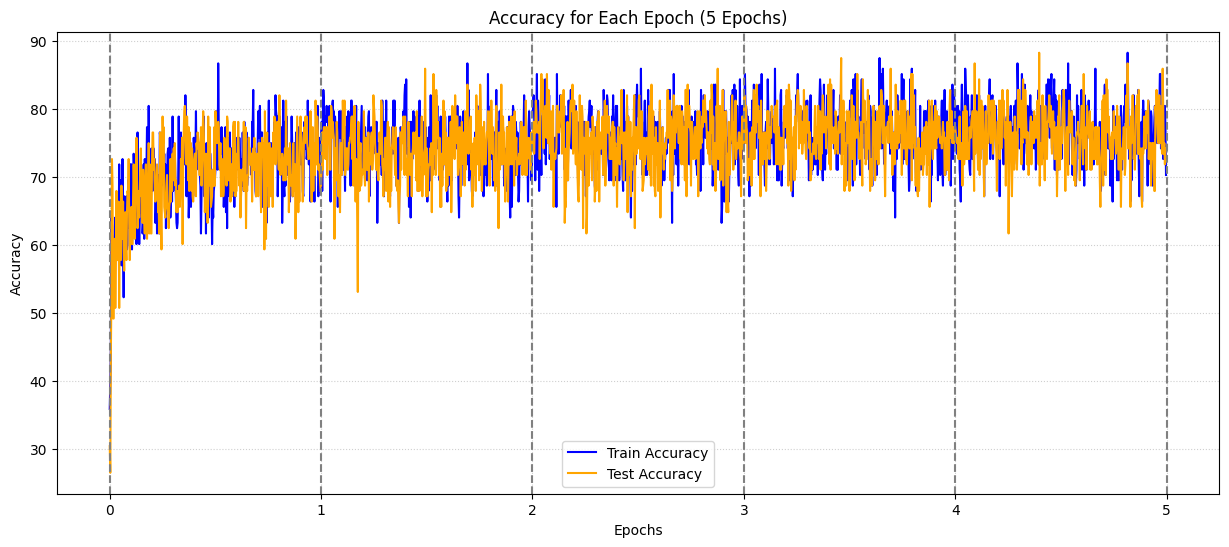

In [ ]:
# Plotting Accuracy
plt.figure(figsize=(15, 6))

# Plot Train Data in one color
for i in range(num_epochs):
    plt.plot(range(i * num_iterations, (i + 1) * num_iterations),
             accuracy_train[i],
             color='blue')  # Fixed color for train

# Plot Test Data in another color
for i in range(num_epochs):
    plt.plot(range(i * num_iterations, (i + 1) * num_iterations),
             accuracy_test[i],
             color='orange')  # Fixed color for test

# Add vertical grid lines for epoch boundaries
for i in range(0, num_epochs+1):
    plt.axvline(x=i * num_iterations, color='gray', linestyle='--')

plt.title(f"Accuracy for Each Epoch ({num_epochs} Epochs)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
epoch_ticks = [i * num_iterations for i in range(num_epochs + 1)]  # Epoch start points
epoch_labels = [f"{i}" for i in range(num_epochs + 1)]  # Labels

plt.xticks(epoch_ticks, epoch_labels)
# Legend for Train and Test
plt.plot([], [], color='blue', label='Train Accuracy')
plt.plot([], [], color='orange', label='Test Accuracy')
plt.legend()

plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# CALCULATING ACCURACY FOR THE ENTIRE TEST SPLIT

In [ ]:
#Using same method of accuracy calculation, calculate accuracy of entire test set.
total = 0
correct = 0
with torch.no_grad():
  model.eval()
  for data, targets in test_loader:
    data = data
    targets = targets

    #forward pass
    _,test_spk = model(data.view(data.size(0), -1))

    #calculate accuracy
    _, predicted = test_spk.sum(dim=0).max(1)
    total += targets.size(0)
    correct += (predicted == targets).sum().item()

print(f"Total correctly classified test set images: {correct}/{total}")
print(f"Test Set Accuracy: {100 * correct / total:.2f}%")

noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
noise
Total correctly 

# STORING FINAL WEIGHTS AND OTHER IMPORTANT VARIABLES

In [ ]:
checkpoint = {
    'model_state': model.state_dict(),
    'num_epochs':num_epochs,
    'num_iterations':num_iterations,
    'optimizer_state': optimizer.state_dict(),
    'accuracy_train': accuracy_train,
    'accuracy_test': accuracy_test,
    'loss_hist': loss_hist,
    'test_loss_hist': test_loss_hist,
}
#torch.save(checkpoint, "/content/drive/My Drive/Noise_Final.pth")

#MEMBRANE POTENTIAL STEM PLOT

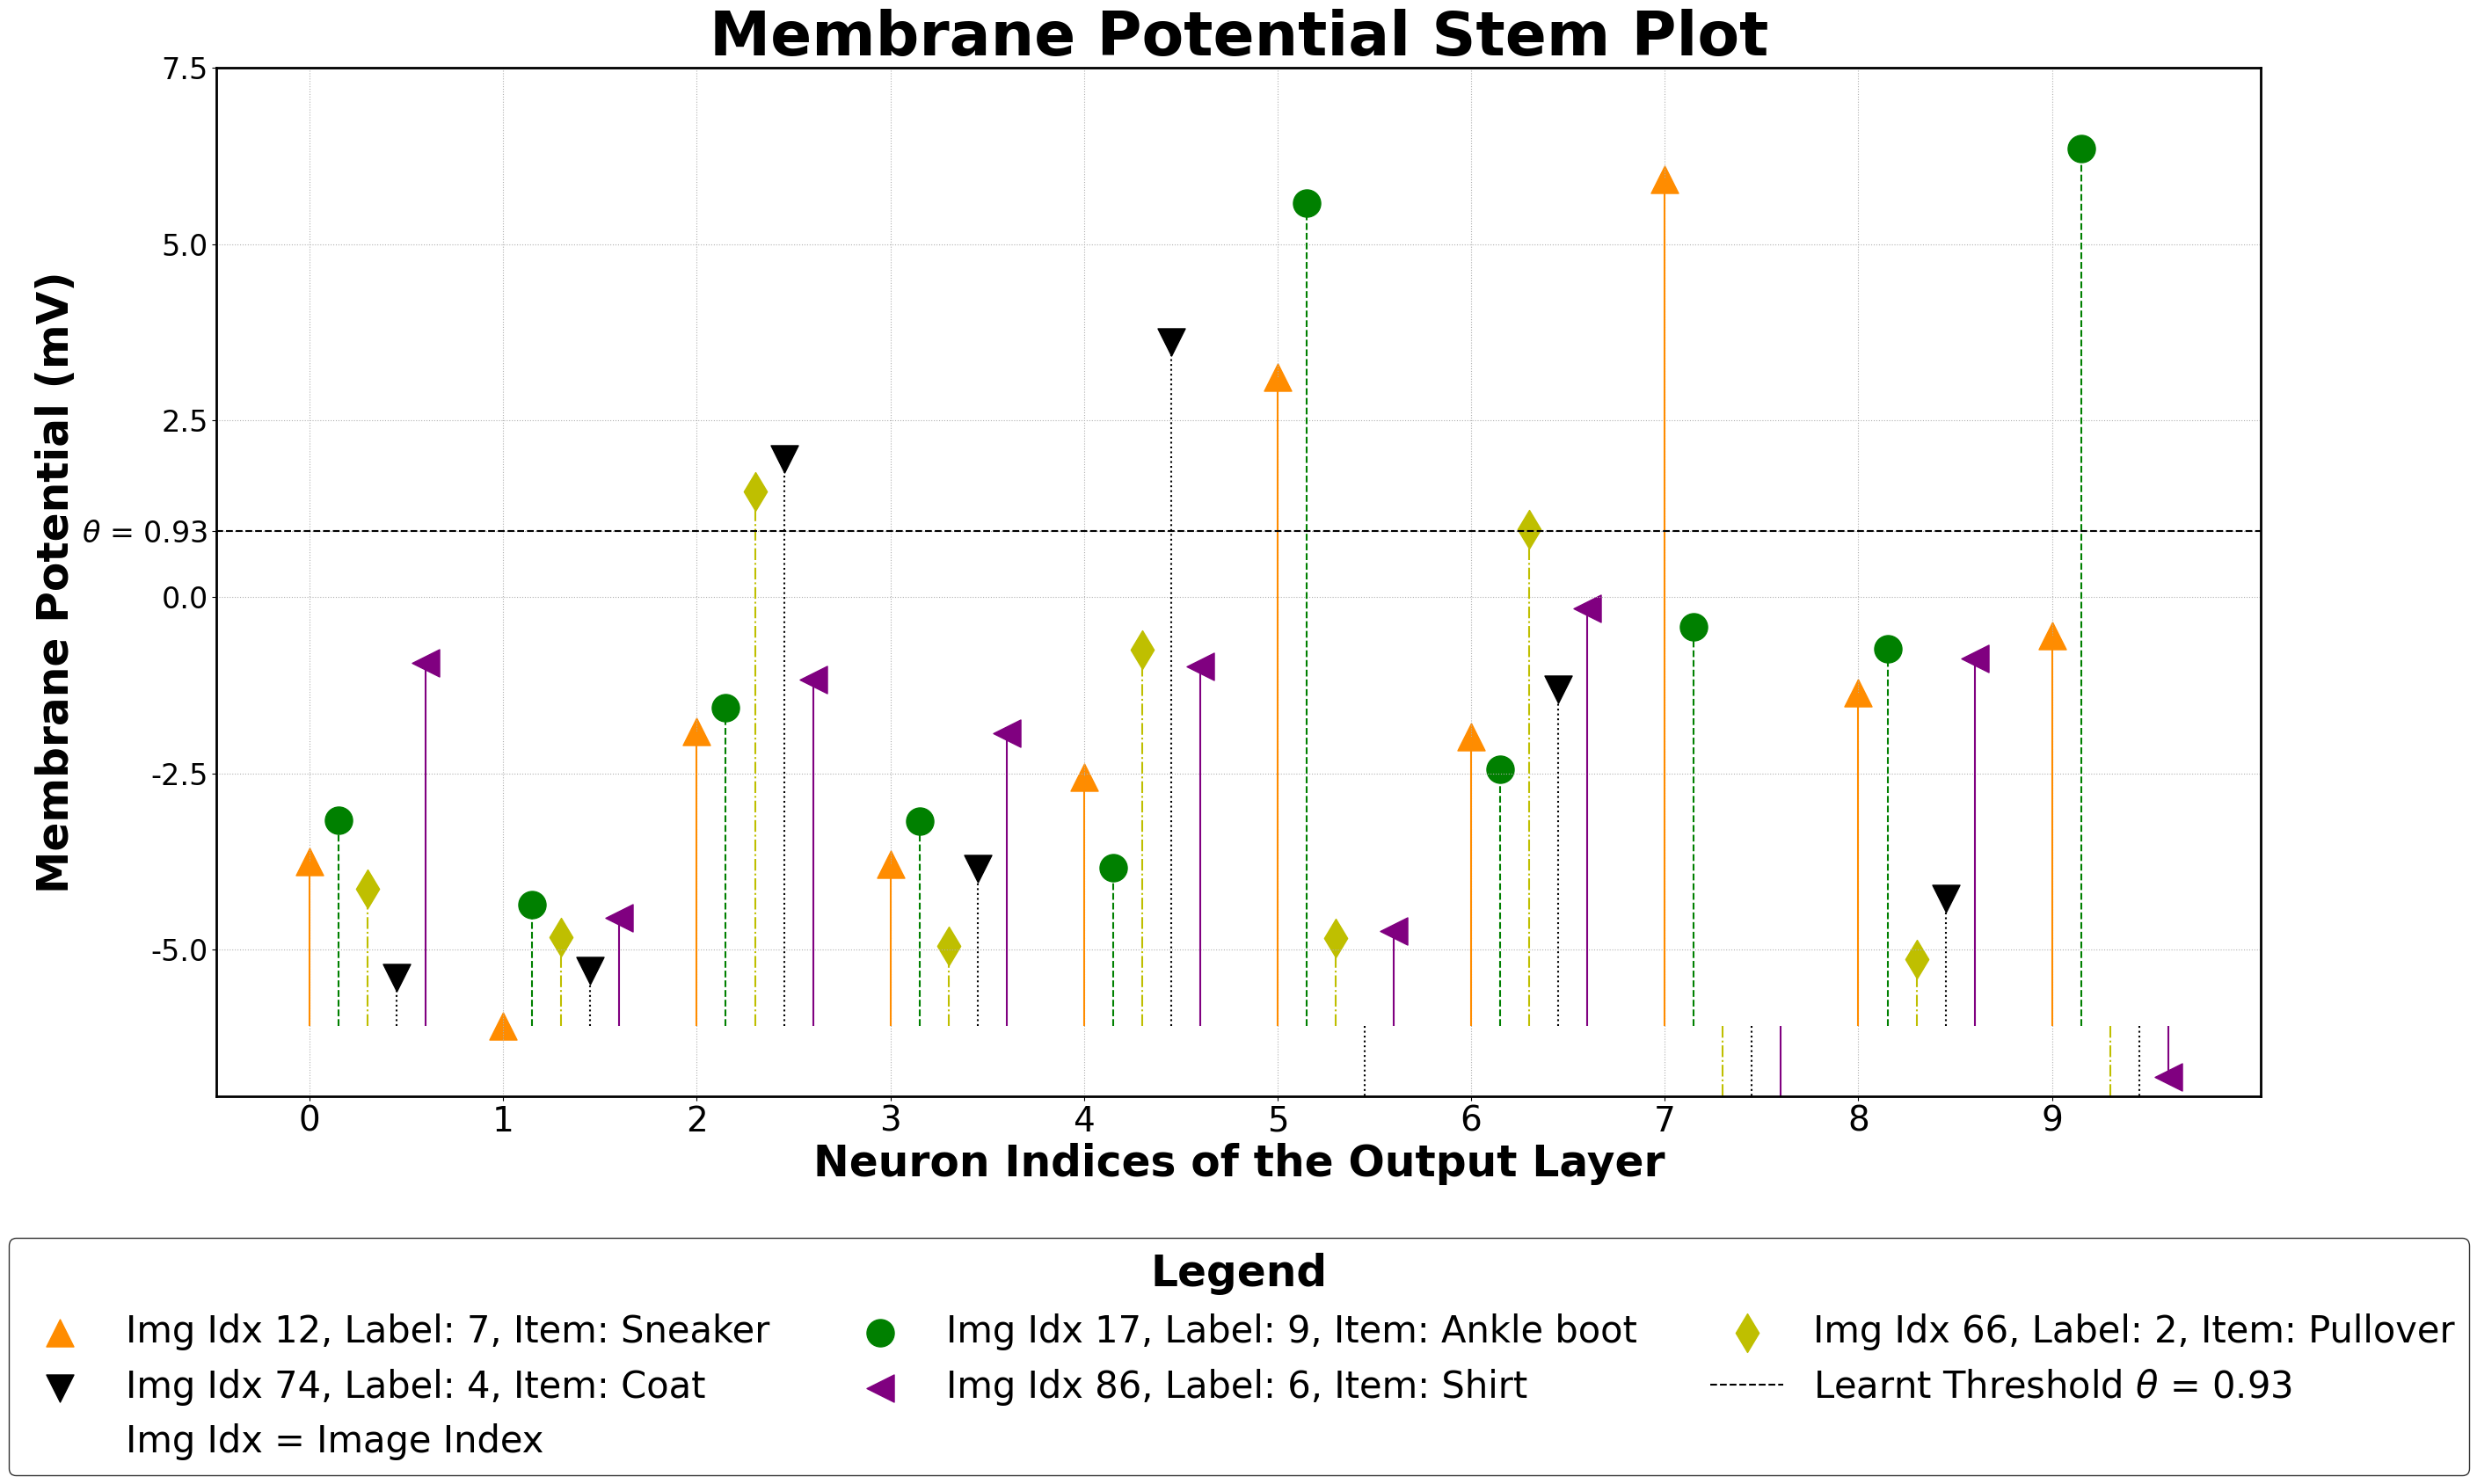

In [ ]:
# Mapping of classes to clothing items
mnist_classes=[0,1,2,3,4,5,6,7,8,9]
fashion_mnist_classes = [
    "T-shirt/top",     # 0
    "Trouser",         # 1
    "Pullover",        # 2
    "Dress",           # 3
    "Coat",            # 4
    "Sandal",          # 5
    "Shirt",           # 6
    "Sneaker",         # 7
    "Bag",             # 8
    "Ankle boot"       # 9
]

if choice_dataset == 0:
  classes = mnist_classes
else:
  classes = fashion_mnist_classes
# Converting membrane potential output to numpy array
mem_rec_plot = mem_rec.detach().cpu().numpy()

line_styles = ['-', '--', '-.', ':']
markers = ['^', 'o',  'd', 'v', '<', '>', 'p', 'h']
colors = ['darkorange', 'g', 'y', 'k', 'purple', 'brown']
marker_cycle = itertools.cycle(markers)
color_cycle = itertools.cycle(colors)
style_cycle = itertools.cycle(line_styles)
image_index = []

# Identification of correctly classified samples
unique_labels = []
for i in range(batch_size):
    max_ = float('-inf')
    max_index = -1
    for j in range(output_neurons):
        temp = mem_rec_plot[num_steps - 1, i, j]  # Use correct indexing
        if max_ < temp:
            max_ = temp
            max_index = j
    if max_index == test_targets[i] and test_targets[i] not in unique_labels:
        image_index.append(i)
        unique_labels.append(test_targets[i])

# Create main figure
fig, ax = plt.subplots(figsize=(30, 15)) # Increased size for better readability
handles = []  # Store legend handles
labels = []   # Store legend labels
for idx in range(5):
  min_y = np.min([mem_rec_plot[num_steps - 1, h].min() for h in image_index[:2]])


  color = next(color_cycle)
  marker = next(marker_cycle)
  style = next(style_cycle)
  offset = 0.15
  x_values = np.arange(mem_rec_plot.shape[2]) + (idx * offset)
  y_values = mem_rec_plot[num_steps - 1, image_index[idx]]

  label_idx = test_targets[image_index[idx]]
  label_name = classes[label_idx]


  if choice_dataset == 0:
    sc = ax.scatter(x_values, y_values,
                  label=f"Img Idx {image_index[idx]}, Label: {label_idx}",
                  color=color, marker=marker, s=500)

    labels.append(f"Img Idx {image_index[idx]}, Label: {label_idx}")
  else:
    sc = ax.scatter(x_values, y_values,
                  label=f"Img Idx {image_index[idx]}, Label: {label_idx}, Item: {label_name}",
                  color=color, marker=marker, s=500)

    labels.append(f"Img Idx {image_index[idx]}, Label: {label_idx}, Item: {label_name}")
  handles.append(sc)  # Store handle

  for x, y in zip(x_values, y_values):
      ax.vlines(x, ymin=min_y, ymax=y, color=color, linestyle=style)


# Plot threshold line
for name, param in model.named_parameters():
    if "lif4.threshold" in name:
        threshold_value = round(param.item(), 2)
        ax.axhline(y=threshold_value, color='black', linestyle='--')  # Just draw the line

        # Manually create a handle for the legend
        handles.append(plt.Line2D([0], [0], color='black', linestyle='--', label=f"Learnt Threshold $\\theta$ = {threshold_value}"))
        labels.append(f"Learnt Threshold $\\theta$ = {threshold_value}")
yticks = plt.yticks()[0]
yticks = np.append(yticks, threshold_value)  # Add the threshold tick

# Define labels (convert to strings and add the threshold symbol)
ytick_labels = [str(tick) for tick in yticks]
ytick_labels[-1] = fr"$\theta$ = {threshold_value}"

handles.append(plt.Line2D([0], [0], marker='o', color='w', label="Img Idx = Image Index", markerfacecolor='w', markersize=10))
labels.append("Img Idx = Image Index")

# Apply the updated ticks and labels
plt.yticks(yticks, ytick_labels)
plt.title("Membrane Potential Stem Plot", fontsize=50, fontweight='bold')
ax.set_xlabel("Neuron Indices of the Output Layer", fontsize=35, fontweight='bold')
ax.set_ylabel("Membrane Potential (mV)", fontsize=35, fontweight='bold')
ax.set_xticks(np.arange(0, output_neurons))
ax.tick_params(axis='x', labelsize=28)
ax.tick_params(axis='y', labelsize=24)
ax.set_ylim(min_y-1, )
ax.grid(True, linestyle=":")

# Adjust space to the right for the legend
plt.subplots_adjust(bottom=0.1)  # Increase space for a 3-row legend
# Reorder handles and labels row-first for legend display
def rowwise_legend_order(handles, labels, ncol):
    n = len(labels)
    nrow = (n + ncol - 1) // ncol  # Total number of rows
    reordered_handles = []
    reordered_labels = []
    for row in range(nrow):
        for col in range(ncol):
            index = col * nrow + row  # This is the fix: column-major to row-major
            if index < n:
                reordered_handles.append(handles[index])
                reordered_labels.append(labels[index])
    return reordered_handles, reordered_labels


# Set number of columns for legend
ncol = 3

# Reorder the legend items
handles, labels = rowwise_legend_order(handles, labels, ncol)
legend = ax.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    ncol=ncol,
    fontsize=30,
    frameon=True,
    title="Legend",
    title_fontsize=35
)

legend.get_frame().set_edgecolor('black')
title_text = legend.get_title()
title_text.set_fontweight('bold')

# Center the last row (if odd number of items)
if len(labels) % ncol == 1:  # Only if one item on last row
    legend._legend_box.align = "center"

# Make the plot border darker and thicker
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2.0)

plt.show()